# code for analyzing differences between immediate & delayed recall

### imports

In [1]:
import numpy as np
import pandas as pd
import hypertools as hyp
import os
import re
import pickle
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr, norm, t, normaltest, f_oneway, wilcoxon

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_context('talk')

### set paths

In [2]:
data_dir = '../../data'
ep_traj_dir = f'{data_dir}/models/episodes/trajectories'
ep_events_dir = f'{data_dir}/models/episodes/events'
rec_traj_dir = f'{data_dir}/models/recalls/trajectories'
rec_events_dir = f'{data_dir}/models/recalls/events'
pickle_dir = f'{data_dir}/pickles'
fig_dir = '../../paper/figures'

### load data

In [127]:
# episode trajectories
episode_traj = np.load(os.path.join(ep_traj_dir, 'atlep1_trajectory.npy'))

# episode events
episode_events = np.load(os.path.join(ep_events_dir, 'atlep1_events.npy'))

# recall trajectories
immediate_trajs = {}
for file in os.listdir(os.path.join(rec_traj_dir, 'atlep1')):
    if file.startswith('debug'):
        immediate_trajs[file.replace('.npy', '')] = np.load(os.path.join(rec_traj_dir, 'atlep1', file))
        
delayed_trajs = {}
for file in os.listdir(os.path.join(rec_traj_dir, 'delayed')):
    if file.startswith('debug'):
        delayed_trajs[os.path.splitext(file)[0]] = np.load(os.path.join(rec_traj_dir, 'delayed', file))
        
# average recall trajectories
avg_imm_traj = np.load(os.path.join(rec_traj_dir, 'atlep1', 'avg_trajectory.npy'))
avg_del_traj = np.load(os.path.join(rec_traj_dir, 'delayed', 'avg_trajectory.npy'))

# recall events
immediate_events = {}
for file in os.listdir(os.path.join(rec_events_dir, 'atlep1')):
    if file.startswith('debug'):
        immediate_events[file.replace('.npy', '')] = np.load(os.path.join(rec_events_dir, 'atlep1', file))
        
delayed_events = {}
for file in os.listdir(os.path.join(rec_events_dir, 'delayed')):
    if file.startswith('debug'):
        delayed_events[os.path.splitext(file)[0]] = np.load(os.path.join(rec_events_dir, 'delayed', file))
        
# average recall events
avg_imm_events = np.load(os.path.join(rec_events_dir, 'atlep1', 'avg_events.npy'))
avg_del_events = np.load(os.path.join(rec_events_dir, 'delayed', 'avg_events.npy'))

# episode-recall event mappings
imm_event_mappings = np.load(os.path.join(rec_events_dir, 'atlep1', 'event_mappings.npy'), allow_pickle=True)
del_event_mappings = np.load(os.path.join(rec_events_dir, 'delayed', 'event_mappings.npy'), allow_pickle=True)

# across-session ID mapppings
with open(os.path.join(pickle_dir,'id_maps.p'), 'rb') as f:
    id_maps = pickle.load(f)

### functions

In [5]:
def r2z(r):
    """
    Function that calculates the Fisher z-transformation

    Parameters
    ----------
    r : int or ndarray
        Correlation value

    Returns
    ----------
    result : int or ndarray
        Fishers z transformed correlation value
    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return 0.5 * (np.log(1 + r) - np.log(1 - r))

In [6]:
def z2r(z):
    """
    Function that calculates the inverse Fisher z-transformation

    Parameters
    ----------
    z : int or ndarray
        Fishers z transformed correlation value

    Returns
    ----------
    result : int or ndarray
        Correlation value
    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

In [7]:
def corr_mean(rs, axis=0):
    """
    Function that calculates the mean of correlation coefficients,
    performing Fisher z-transformation and inverse z-transormation
    
    Parameters
    ----------
    rs : list or ndarray
        Correlation values
    
    Returns
    ----------
    result : float
        mean of correlation values
    """
    return z2r(np.nanmean([r2z(r) for r in rs], axis=axis))

In [8]:
def corr_pearsonr(rs1, rs2):
    return pearsonr(r2z(np.array(rs1)), r2z(np.array(rs2)))

In [8]:
# def corr_sigdiff_ind(r1n1, r2n2):
#     """
#     Function that performs Fisher (1925)'s test for comparison of two
#     correlation coefficients based on independent groups.
    
#     Parameters
#     ----------
#     r1n1, r2n2 : list-like
#         2-item iterables of (correlation coefficient, sample size)
#         for the two groups being compared
        
#     Returns
#     ----------
#     z : float
#         Test statistic
        
#     p : float
#         Two-tailed p-value
#     """
    
#     for arg in [r1n1, r2n2]:
#         if not hasattr(arg, '__iter__') or isinstance(arg, str):
#             raise TypeError("arguments should be list-like with len 2: \
#             (correlation coefficient, sample size)")
    
#     r1, n1 = r1n1
#     r2, n2 = r2n2
    
#     z = (r2z(r1) - r2z(r2)) / np.sqrt(1/(n1-3) + 1/(n2-3))
#     p = norm.sf(np.abs(z)) * 2 # two-sided
#     return (z, p)

In [8]:
# def corr_sigdiff_ind(r1n1, r2n2, n_obs1=None, n_obs2=None):
#     """
#     Function that returns the inverse z-transformed difference 
#     between two correlation coefficients from independent samples
#     of different sizes
    
#     Parameters
#     ----------
#     r1n1 : tup of floats or ndarray
#         sample 1's correlation value and number of observations
#     r2n2 : tup of floats or ndarray
#         sample 2's correlation value and number of observations
#     obs1 : int
#         if r1n1 and r2n2 are ndarrays, the number of observations that
#         went into calculating r1n1
#     obs2 : int
#         if r1n1 and r2n2 are ndarrays, the number of observations that
#         went into calculating r2n2
    
#     Returns
#     ----------
#     coff_diff : float
#         difference between correlation coefficients 
    
#     """
#     if isinstance(r1n1, np.ndarray) and isinstance(r2n2, np.ndarray):
#         Z_diff = (_r2z(r1n1) - _r2z(r2n2)) / np.sqrt(1/(n_obs1-3) + 1/(n_obs2-3))
        
    
#     elif isinstance(r1n1, tuple) and isinstance(r2n2, tuple):
#         r1, n1 = r1n1
#         r2, n2 = r2n2
#         Z_diff = _z2r((_r2z(r1) - _r2z(r2)) / np.sqrt(1/(n1-3) + 1/(n2-3)))
    
#     else:
#         raise ValueError("both arguments must be the same type")
        
#     return (Z_diff, norm.sf(abs(Z_diff))*2)

In [8]:
def ribbon(M, color='k', alpha=0.5, label=None):
    # for plotting 95% CI bars
    x = np.arange(M.shape[0])
    y = np.mean(M, axis=1)
    ci = 1.96 * np.divide(np.std(M, axis=1), np.sqrt(M.shape[1] - 1))
    
    h1 = plt.fill_between(x, y - ci, y + ci, color=color, alpha=alpha)
    h2 = plt.plot(x, y, color=color, label=label)
    return h1, h2

In [845]:
def bootstrap_ci(M, ci=95, n_boots=1000, color='#1f77b4', alpha=0.3, corrs=False, return_bounds=False, label=None):
    evs = np.arange(M.shape[0])
    y = corr_mean(M, axis=1) if corrs else M.mean(axis=1)
    ci_low = (100 - ci) / 2
    ci_high = 100 - ci_low
    L, U = np.empty(evs.shape), np.empty(evs.shape)
    # constructs a single resample
    boot_mean = lambda x: np.random.choice(x, size=len(x), replace=True).mean()
    
    for ev in evs:
        ev_dists = r2z(M[ev]) if corrs else M[ev]
        boot_iter = (boot_mean(ev_dists) for n in range(n_boots))
        boots = np.fromiter(boot_iter, dtype=float)
        # use percentile bootstrap (seaborn default method)
        L[ev], U[ev] = np.percentile(boots, ci_low), np.percentile(boots, ci_high)
        if corrs:
            L[ev], U[ev] = z2r(L[ev]), z2r(U[ev])
    
    # error ribbons
    h1 = plt.fill_between(evs, L, U, color=color, alpha=alpha)
    # opaque line
    h2 = plt.plot(evs, y, color=color, label=label)
    returns = [h1, h2]
    if return_bounds:
        returns.extend([L, U])
    return returns

In [24]:
# # stashing correlation CI calcualtion for now -- wrong use case?
# def ribbon(M, color='k', alpha=0.5, label=None, corrs=False):    
#     x = np.arange(M.shape[0])
    
#     if corrs:
#         y = corr_mean(M, axis=1)
#     else:
#         y = np.mean(M, axis=1)
        
#     ci = 1.96 * np.divide(np.nanstd(M, axis=1), np.sqrt(M.shape[1] - 1))
        
#     h1 = plt.fill_between(x, y - ci, y + ci, color=color, alpha=alpha)
#     h2 = plt.plot(x, y, color=color, label=label)
#     return h1, h2

In [828]:
def fill_precision_df(sub):
    imm_turkid = id_maps.loc[sub.name, 'session 1']
    del_turkid = id_maps.loc[sub.name, 'session 2']
    
    imm_mappings = imm_event_mappings[np.where(imm_event_mappings == imm_turkid)[0]].ravel()[1]
    del_mappings = del_event_mappings[np.where(del_event_mappings == del_turkid)[0]].ravel()[1]
    
    imm_corrs = np.diag(1 - cdist(immediate_events[imm_turkid], episode_events[imm_mappings], 'correlation'))
    del_corrs = np.diag(1 - cdist(delayed_events[del_turkid], episode_events[del_mappings], 'correlation'))
    
    for ix, ev in enumerate(imm_mappings):
        # inequalities except != with np.nan always return False
        if not sub.loc[(ev, 'immediate')] > imm_corrs[ix]:
            sub.loc[(ev, 'immediate')] = imm_corrs[ix]
            
    for ix, ev in enumerate(del_mappings):
        if not sub.loc[(ev, 'delayed')] > del_corrs[ix]:
            sub.loc[(ev, 'delayed')] = del_corrs[ix]
            
    for ev in range(n_events):
        sub.loc[(ev, 'change')] = sub.loc[(ev, 'immediate')] - sub.loc[(ev, 'delayed')]
        
    return sub 

# compare by timepoint

In [24]:
n_participants = id_maps.shape[0]
n_timepoints = episode_traj.shape[0]

### recall precision
How does participants' performance compare between immediate and delayed recall?

In [10]:
# # not as good a way? 
# # This is "precision of average participant," not "average precision across participants"

# immediate_corr = np.diag(1-cdist(avg_imm_traj, episode_traj, metric='correlation'))
# delayed_corr = np.diag(1-cdist(avg_del_traj, episode_traj, metric='correlation'))

In [11]:
# plt.plot(immediate_corr, color='red')
# plt.plot(delayed_corr, color='skyblue')
# plt.xlim(0, 1466)
# plt.ylim(0, 1)
# plt.tight_layout()
# plt.show()

In [361]:
imm_precision = np.zeros((n_participants, n_timepoints))
del_precision = np.zeros((n_participants, n_timepoints))

for ix, (_, subID) in enumerate(id_maps.iterrows()):
    imm_precision[ix] = np.diag(1 - cdist(immediate_trajs[subID['session 1']], episode_traj, 'correlation'))
    del_precision[ix] = np.diag(1 - cdist(delayed_trajs[subID['session 2']], episode_traj, 'correlation'))

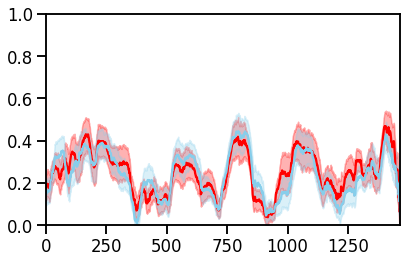

In [26]:
bootstrap_ci(imm_precision.T, color='red')
bootstrap_ci(del_precision.T, color='skyblue')
plt.xlim(0, n_timepoints-1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

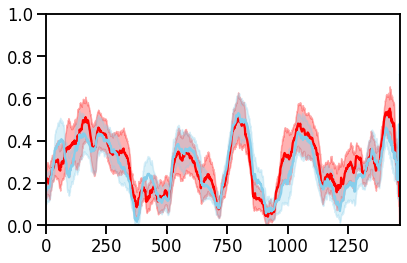

In [32]:
# version treating precision as correlations
bootstrap_ci(imm_precision.T, color='red', corrs=True)
bootstrap_ci(del_precision.T, color='skyblue', corrs=True)
plt.xlim(0, n_timepoints-1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### change in precision
How much information did participants lose (or gain) over the delay period?

In [28]:
precision_change = imm_precision - del_precision

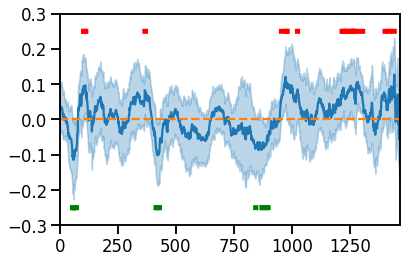

In [124]:
# red - tpts remembered better immediately
# green - tpts remembered better after delay
_, _, L, U = bootstrap_ci(precision_change.T, return_bounds=True)
sigmask_low = np.ma.masked_where(L <= 0, np.full_like(L, .25))
sigmask_high = np.ma.masked_where(U >= 0, np.full_like(U, -.25))
plt.plot(sigmask_low.filled(np.nan), color='red', linewidth=5)
plt.plot(sigmask_high.filled(np.nan), color='green', linewidth=5)
plt.axhline(0, linestyle='--', color='#ff7f0e')
plt.xlim(0, n_timepoints-1)
plt.ylim(-.3, .3)
plt.tight_layout()
plt.show()

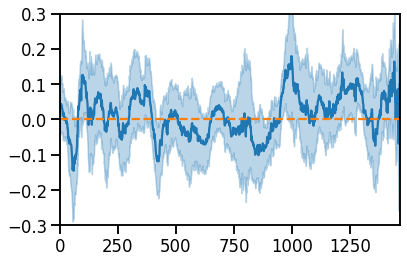

In [33]:
# version treating precision as correlations
bootstrap_ci(precision_change.T, corrs=True)
plt.axhline(0, linestyle='--', color='#ff7f0e')
plt.xlim(0, n_timepoints-1)
plt.ylim(-.3, .3)
plt.tight_layout()
plt.show()

### recall content variability across participants
How similar are participants' recall contents (to each other) in each session?

In [128]:
# currently using correlation between individual recall topic vector and average recall topic vector
# maybe better to do timepoint-wise standard deviation across participants, than average over topic dimensions?
imm_var = np.zeros((n_participants, n_timepoints))
del_var = np.zeros((n_participants, n_timepoints))

for ix, (_, subID) in enumerate(id_maps.iterrows()):
    imm_var[ix] = np.diag(1-cdist(immediate_trajs[subID['session 1']], avg_imm_traj, 'correlation'))
    del_var[ix] = np.diag(1-cdist(delayed_trajs[subID['session 2']], avg_del_traj, 'correlation'))

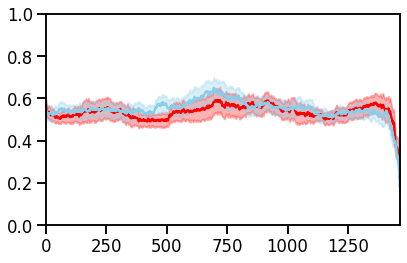

In [132]:
bootstrap_ci(imm_var.T, color='red')
bootstrap_ci(del_var.T, color='skyblue')
plt.xlim(0, n_timepoints-1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### change in content variability across participants
Does participants' recall content converge or diverge over the delay period?

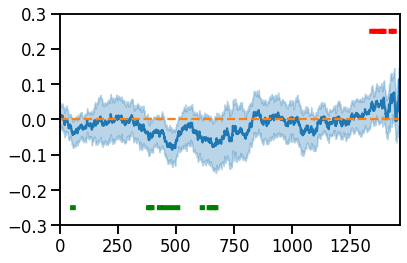

In [145]:
# red - tpts recalled more similarly immediately
# green - tpts recalled more similarly after delay
_, _, L, U = bootstrap_ci(var_change.T, return_bounds=True)
sigmask_low = np.ma.masked_where(L <= 0, np.full_like(L, .25))
sigmask_high = np.ma.masked_where(U >= 0, np.full_like(U, -.25))
plt.plot(sigmask_low.filled(np.nan), color='red', linewidth=5)
plt.plot(sigmask_high.filled(np.nan), color='green', linewidth=5)
plt.axhline(0, linestyle='--', color='#ff7f0e')
plt.xlim(0, n_timepoints-1)
plt.ylim(-.3, .3)
plt.tight_layout()
plt.show()

### recall precision variability across participants
How much variability is there are participants' memory performances for each session?

In [168]:
# imm_prec_var = imm_precision - imm_precision.mean(axis=0)
# del_prec_var = del_precision - del_precision.mean(axis=0)
imm_prec_var = imm_precision.std(axis=0)
del_prec_var = del_precision.std(axis=0)

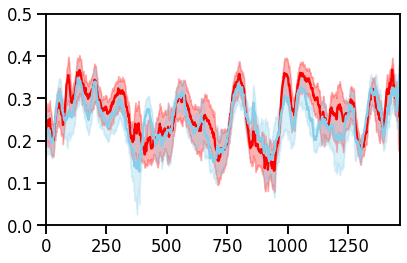

In [186]:
# standard deviation with 95% bootstrap CI's
imm_L, imm_U = np.empty(n_timepoints), np.empty(n_timepoints)
del_L, del_U = np.empty(n_timepoints), np.empty(n_timepoints)
boot_std = lambda x: np.random.choice(x, size=len(x), replace=True).std()

for tpt in range(n_timepoints):
    imm_boot_iter = (boot_std(imm_precision.T[tpt]) for n in range(1000))
    del_boot_iter = (boot_std(del_precision.T[tpt]) for n in range(1000))
    imm_boots = np.fromiter(imm_boot_iter, dtype=float)
    del_boots = np.fromiter(del_boot_iter, dtype=float)
    imm_L[tpt], imm_U[tpt] = np.percentile(imm_boots, 2.5), np.percentile(imm_boots, 97.5)
    del_L[tpt], del_U[tpt] = np.percentile(del_boots, 2.5), np.percentile(del_boots, 97.5)

plt.fill_between(np.arange(n_timepoints), imm_L, imm_U, color='red', alpha=.3)
plt.plot(imm_precision.std(axis=0), color='red')
plt.fill_between(np.arange(n_timepoints), del_L, del_U, color='skyblue', alpha=.3)
plt.plot(del_precision.std(axis=0), color='skyblue')
plt.xlim(0, n_timepoints-1)
plt.ylim(0, .5)
plt.tight_layout()
plt.show()

### change in precision variability across participants
Does memory performance converge or diverge over the delay period?

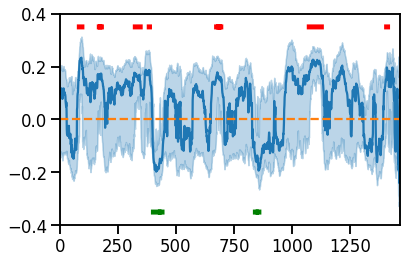

In [287]:
change_L, change_U = np.empty(n_timepoints), np.empty(n_timepoints)
# can't add/subtract standard deviations, have to use variance and then convert
boot_var_diff = lambda x,y: np.random.choice(x, size=len(x), replace=True).var() \
                            - np.random.choice(y, size=len(y), replace=True).var()

for tpt in range(n_timepoints):
    vardiff_boot_iter = (boot_var_diff(imm_precision.T[tpt], del_precision.T[tpt]) for n in range(1000))
    vardiff_boots = np.fromiter(vardiff_boot_iter, dtype=float)
    # convert to standard deviation, preserve negative differences
    stddiff_boots = np.where(vardiff_boots > 0, np.sqrt(vardiff_boots), np.negative(np.sqrt(np.abs(vardiff_boots))))
    change_L[tpt], change_U[tpt] = np.percentile(stddiff_boots, 2.5), np.percentile(stddiff_boots, 97.5)
    
mean_vardiff = imm_precision.var(axis=0) - del_precision.var(axis=0)
mean_stddiff = np.where(mean_vardiff > 0, np.sqrt(mean_vardiff), np.negative(np.sqrt(np.abs(mean_vardiff))))

plt.fill_between(np.arange(n_timepoints), change_L, change_U, color='#1f77b4', alpha=.3)
plt.plot(mean_stddiff, color='#1f77b4')
sigmask_low = np.ma.masked_where(change_L <= 0, np.full_like(change_L, .35))
sigmask_high = np.ma.masked_where(change_U >= 0, np.full_like(change_U, -.35))
plt.plot(sigmask_low.filled(np.nan), color='red', linewidth=5)
plt.plot(sigmask_high.filled(np.nan), color='green', linewidth=5)
plt.axhline(0, linestyle='--', color='#ff7f0e')
plt.xlim(0, n_timepoints-1)
plt.ylim(-.4, .4)
plt.tight_layout()
plt.show()

# compare by event

In [829]:
n_events = episode_events.shape[0]

### recall precision

# version using only best matched event

In [830]:
multiindex = pd.MultiIndex.from_product([list(range(episode_events.shape[0])), ['immediate', 'delayed', 'change']],
                                        names=['event', 'precision'])
event_precision = pd.DataFrame(index=multiindex, columns=id_maps.index, dtype=np.float64)

In [831]:
event_precision = event_precision.apply(fill_precision_df, result_type='broadcast')

/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/ipykernel_launcher.py:5: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  """
/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/ipykernel_launcher.py:6: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  


In [832]:
event_precision.head()

MD-101218-A-01  MD-101218-B-01  MD-101218-A-02  \
event precision                                                   
0     immediate             NaN             NaN             NaN   
      delayed               NaN        0.603559             NaN   
      change                NaN             NaN             NaN   
1     immediate        0.656544             NaN             NaN   
      delayed               NaN             NaN             NaN   

                 MD-101218-B-02  MD-101218-A-03  MD-101218-B-03  \
event precision                                                   
0     immediate             NaN        0.648072             NaN   
      delayed               NaN             NaN             NaN   
      change                NaN             NaN             NaN   
1     immediate             NaN        0.775545             NaN   
      delayed          0.856236        0.685059        0.670832   

                 MD-101218-A-04  MD-101318-B-01  MD-101318-B-02  \
event precision                                                   
0     immediate             NaN             NaN             NaN   
      delayed               NaN             NaN             NaN   
      change                NaN             NaN             NaN   
1     immediate             NaN        0.644941             NaN   
      delayed               NaN        0.711414             NaN   

                 MD-101318-A-02  ...  MD-021519-A-01  MD-021819-B-01  \
event precision                  ...                                   
0     immediate             NaN  ...             NaN             NaN   
      delayed               NaN  ...             NaN             NaN   
      change                NaN  ...             NaN             NaN   
1     immediate             NaN  ...             NaN        0.918422   
      delayed          0.690108  ...        0.934212             NaN   

                 MD-021819-B-02  MD-021919-A-01  MD-021919-B-01  \
event precision                                                   
0     immediate             NaN             NaN             NaN   
      delayed               NaN             NaN             NaN   
      change                NaN             NaN             NaN   
1     immediate             NaN             NaN             NaN   
      delayed               NaN             NaN             NaN   

                 MD-021919-A-02  MD-022519-A-01  MD-022719-A-01  \
event precision                                                   
0     immediate             NaN             NaN             NaN   
      delayed               NaN             NaN        0.534845   
      change                NaN             NaN             NaN   
1     immediate             NaN        0.599945        0.686864   
      delayed               NaN             NaN             NaN   

                 MD-022819-B-01  MD-022819-B-02  
event precision                                  
0     immediate             NaN             NaN  
      delayed          0.555375             NaN  
      change                NaN             NaN  
1     immediate             NaN             NaN  
      delayed               NaN             NaN  

[5 rows x 57 columns]

In [833]:
def bootstrap_ci_nan(M, ci=95, n_boots=1000, color='#1f77b4', alpha=0.3, corrs=False, return_bounds=False, label=None):
    evs = np.arange(M.shape[0])
    y = corr_mean(M, axis=1) if corrs else np.nanmean(M, axis=1)
    ci_low = (100 - ci) / 2
    ci_high = 100 - ci_low
    L, U = np.empty(evs.shape), np.empty(evs.shape)
    # constructs a single resample
    boot_mean = lambda x: np.random.choice(x, size=len(x), replace=True).mean()
    
    for ev in evs:
        ev_dists = r2z(M[ev][~np.isnan(M[ev])]) if corrs else M[ev][~np.isnan(M[ev])]
        boot_iter = (boot_mean(ev_dists) for n in range(n_boots))
        boots = np.fromiter(boot_iter, dtype=float)
        # use percentile bootstrap (seaborn default method)
        L[ev], U[ev] = np.percentile(boots, ci_low), np.percentile(boots, ci_high)
        if corrs:
            L[ev], U[ev] = z2r(L[ev]), z2r(U[ev])
    # error ribbons
    h1 = plt.fill_between(evs, L, U, color=color, alpha=alpha)
    # opaque line
    h2 = plt.plot(evs, y, color=color, label=label)
    returns = [h1, h2]
    if return_bounds:
        returns.extend([L, U])
    return returns

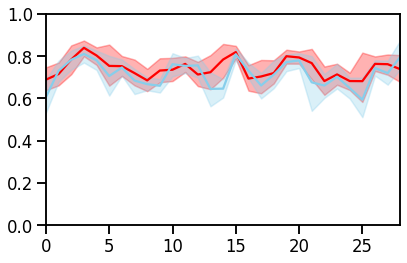

In [834]:
bootstrap_ci_nan(event_precision.xs('immediate', level='precision').values, color='red')
bootstrap_ci_nan(event_precision.xs('delayed', level='precision').values, color='skyblue')
plt.xlim(0, n_events-1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# version using closest recall event for each episode event (current)

In [848]:
imm_precision = np.zeros((n_participants, n_events))
del_precision = np.zeros((n_participants, n_events))

for ix, (_, subID) in enumerate(id_maps.iterrows()):
    imm_recall = immediate_events[subID['session 1']]
    del_recall = delayed_events[subID['session 2']]

    imm_precision[ix] = (1 - cdist(immediate_events[subID['session 1']], episode_events, 'correlation')).max(axis=0)
    del_precision[ix] = (1 - cdist(delayed_events[subID['session 2']], episode_events, 'correlation')).max(axis=0)


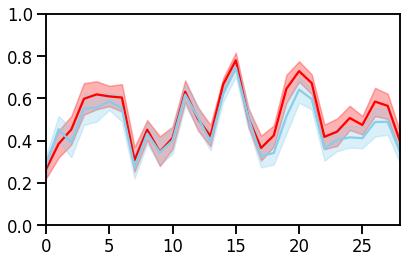

In [849]:
bootstrap_ci(imm_precision.T, color='red')
bootstrap_ci(del_precision.T, color='skyblue')
plt.xlim(0, n_events-1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### change in precision

In [ ]:
# using best MATCHED recall event

In [884]:
precision_change = event_precision.xs('change', level='precision').values

/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: Mean of empty slice
  This is separate from the ipykernel package so we can avoid doing imports until
/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/ipykernel_launcher.py:8: RuntimeWarning: Mean of empty slice.
  


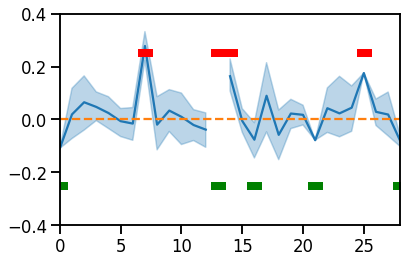

In [960]:
# red - tpts remembered better immediately
# green - tpts remembered better after delay
# plt.ylim(-.4, .4)

_, _, L, U = bootstrap_ci_nan(precision_change, return_bounds=True)
sigmask_low = np.ma.masked_where(L <= 0, np.full_like(L, .25))
sigmask_high = np.ma.masked_where(U >= 0, np.full_like(U, -.25))
plt.plot(sigmask_low.filled(np.nan), marker='_', ms=15, mew=8, color='red')
plt.plot(sigmask_high.filled(np.nan), marker='_', ms=15, mew=8, color='green')
plt.axhline(0, linestyle='--', color='#ff7f0e')
plt.xlim(0, n_events-1)
plt.ylim(-.4, .4)
plt.tight_layout()
plt.show()

In [950]:
L

array([-0.10934994, -0.07613454, -0.03736683, -0.00333204, -0.03217542,
       -0.06444465, -0.08928275,  0.2235868 , -0.11093148, -0.04457313,
       -0.09469204, -0.07974884, -0.1054233 ,         nan,  0.10826947,
       -0.05060158, -0.14796341, -0.04696144, -0.1517553 , -0.03600785,
       -0.01951294, -0.07830389, -0.0488908 , -0.06544756, -0.04962705,
        0.17549115, -0.01688603, -0.06097409, -0.10246167])

In [948]:
np.where(L <= 0)

(array([ 0,  1,  2,  3,  4,  5,  6,  8,  9, 10, 11, 12, 15, 16, 17, 18, 19,
        20, 21, 22, 23, 24, 26, 27, 28]),)

In [954]:
np.where((L <= 0) & ~(np.isnan(L)))

(array([ 0,  1,  2,  3,  4,  5,  6,  8,  9, 10, 11, 12, 15, 16, 17, 18, 19,
        20, 21, 22, 23, 24, 26, 27, 28]),)

In [887]:
L <= 0

array([ True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True, False, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True])

In [888]:
sigmask_low

masked_array(data=[--, --, --, --, --, --, --, 0.25, --, --, --, --, --,
                   0.25, 0.25, --, --, --, --, --, --, --, --, --, --,
                   0.25, --, --, --],
             mask=[ True,  True,  True,  True,  True,  True,  True, False,
                    True,  True,  True,  True,  True, False, False,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True, False,  True,  True,  True],
       fill_value=1e+20)

In [889]:
sigmask_low.filled(np.nan)

array([ nan,  nan,  nan,  nan,  nan,  nan,  nan, 0.25,  nan,  nan,  nan,
        nan,  nan, 0.25, 0.25,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan, 0.25,  nan,  nan,  nan])

In [868]:
# simply using best recall event
precision_change = imm_precision - del_precision

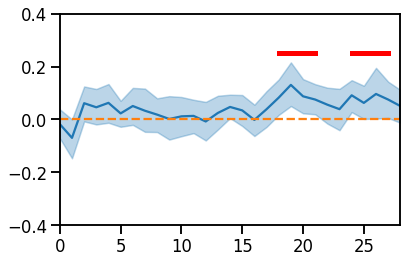

In [869]:
# red - tpts remembered better immediately
# green - tpts remembered better after delay
_, _, L, U = bootstrap_ci(precision_change.T, return_bounds=True)
sigmask_low = np.ma.masked_where(L <= 0, np.full_like(L, .25))
sigmask_high = np.ma.masked_where(U >= 0, np.full_like(U, -.25))
plt.plot(sigmask_low.filled(np.nan), color='red', linewidth=5)
plt.plot(sigmask_high.filled(np.nan), color='green', linewidth=5)
plt.axhline(0, linestyle='--', color='#ff7f0e')
plt.xlim(0, n_events-1)
plt.ylim(-.4, .4)
plt.tight_layout()
plt.show()

In [305]:
# # red - tpts remembered better immediately
# # green - tpts remembered better after delay
# _, _, L, U = bootstrap_ci(precision_change.T, return_bounds=True)
# sigmask_low = np.ma.masked_where(L <= 0, np.full_like(L, .25))
# sigmask_high = np.ma.masked_where(U >= 0, np.full_like(U, -.25))
# plt.plot(sigmask_low.filled(np.nan), color='red', linewidth=5)
# plt.plot(sigmask_high.filled(np.nan), color='green', linewidth=5)
# plt.axhline(0, linestyle='--', color='#ff7f0e')
# plt.xlim(0, n_timepoints)
# plt.ylim(-.3, .3)
# plt.tight_layout()
# plt.show()

### recall content variability

### change in content variability

### recall precision variability

### change in precision variability

In [292]:
imm_event_mappings

array([['debug67jbC:debugFuOd5',
        array([ 3,  6,  7, 11, 15, 16, 21, 22, 26, 26])],
       ['debugSlGFs:debug42TAZ',
        array([ 0, 18, 18, 15, 16, 19, 20, 15, 26, 27, 28])],
       ['debugQ0oPh:debugCquQc',
        array([ 1,  6,  7, 12, 11, 15, 16, 17, 19, 20, 22, 25, 26,  5, 24])],
       ['debugvnS2Q:debugG20gK',
        array([ 4,  5,  6, 13, 14, 19, 20, 20, 22, 24, 26, 27, 28])],
       ['debugAU1cu:debugzdGmZ',
        array([26,  4,  6,  7, 15, 15, 19, 21, 22, 27, 28])],
       ['debuglPelZ:debugtE6HF',
        array([ 2,  4,  6,  8,  9, 11, 15, 19, 20, 15, 27])],
       ['debuglUIy4:debugsomEs',
        array([ 2, 12,  6, 14, 14, 13, 15, 15, 19, 20, 23, 26])],
       ['debug2LQvu:debugk4zJe',
        array([ 1,  3,  4,  6,  8, 10, 11, 13, 20, 20, 23, 24, 26, 27])],
       ['debugiqtcE:debugiPC2h',
        array([ 6, 11, 13, 20, 20, 23, 24, 26, 27])],
       ['debugxhEnD:debugVc60O', array([24,  1, 18, 17, 19, 21, 21, 26])],
       ['debugo1MpX:debugfpXYH',
        a

In [37]:
# immediate recall-episode correlation at each timepoint
sub_evcorrs_i = np.full((59, 32), np.nan) #[[] for _ in range(32)]
sub_evcorrs_d = np.full((59, 32), np.nan) #[[] for _ in range(32)]

for i, (turkid, imm_evs) in enumerate((participant_events['atlep1'])):
    matches_i = next(sub_ms for tid, sub_ms in event_mappings['atlep1'] if tid == turkid)
    event_vars = np.diag(1-cdist(imm_evs, avg_participant_events['atlep1'][matches_i], 'correlation'))
    
    for j, m in enumerate(matches_i):
            sub_evcorrs_i[i][m] = event_vars[j]
                        
for i, (turkid, del_ev) in enumerate((participant_events['delayed'])):
    matches_d = next(sub_ms for tid, sub_ms in event_mappings['delayed'] if tid == turkid)
    event_vars = np.diag(1-cdist(del_ev, avg_participant_events['delayed'][matches_d], 'correlation'))
    
    for j, m in enumerate(matches_d):
            sub_evcorrs_d[i][m] = event_vars[j]


/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/ipykernel_launcher.py:17: RuntimeWarning: Mean of empty slice
/Users/paxtonfitzpatrick/anaconda/envs/py36/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1434: RuntimeWarning: Degrees of freedom <= 0 for slice.
  keepdims=keepdims)


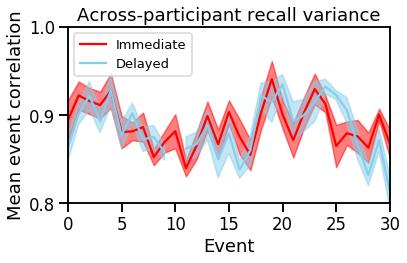

In [50]:
sns.set_context('talk')
ribbon(sub_evcorrs_i.T[:-1], color='red', label='Immediate', corrs=True)
ribbon(sub_evcorrs_d.T[:-1], color='skyblue', label='Delayed', corrs=True)
plt.xlim((0,30))
plt.ylim((0.8,1))
plt.yticks(np.arange(.8, 1.05, 0.1))
plt.title('Across-participant recall variance')#, fontsize=16)
plt.xlabel('Event')#, fontsize=14)
plt.ylabel('Mean event correlation')#, fontsize=14)
plt.legend(loc=2, fontsize=13)
plt.tight_layout()
# plt.savefig(delfig_dir+'immediate-delayed-ev-variance-corr.pdf')

## what event falls during these timepoints

### (to do later)

## try with sherlock-proportional episode windows

In [16]:
# ep_prop_traj_dir = os.path.join(ep_model_dir, 't100_wProp', 'trajectories')
# rec_prop_traj_dir = os.path.join(rec_traj_dir, 'vidwProp')

# # episode trajectories
# episode_trajectories_prop = {episode : np.load(os.path.join(ep_prop_traj_dir, episode+'_model_t100_wProp_res.npy')) 
#                         for episode in ['atlep1','atlep2','arrdev']}

# # individual participant trajectories
# participant_trajectories_prop = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

# for root, dirs, files in os.walk(rec_prop_traj_dir):
#     traj_models = [f for f in files if f.startswith('debug') and f.endswith('.npy')]
#     for f_name in traj_models:
#         t = np.load(os.path.join(root,f_name))
#         participant_trajectories_prop[os.path.split(root)[-1]].append((f_name.split('.')[0],t))
        
# # average participant trajectories
# avg_participant_trajectories_prop = {rectype : np.load(os.path.join(rec_prop_traj_dir, rectype, 
#                                                                     'avg_trajectory.npy')) 
#                                      for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}

In [17]:
# imm_trajs = [traj for turkid, traj in participant_trajectories_prop['atlep1']]
# sub_dists_i = []

# for traj in imm_trajs:
#     sub_dists_i.append(np.diag(cdist(avg_participant_trajectories_prop['atlep1'], traj, metric='euclidean')))

# immediate_variance = np.mean(sub_dists_i, axis=0)

In [18]:
# del_trajs = [traj for turkid, traj in participant_trajectories_prop['delayed']]
# sub_dists_d = []

# for traj in del_trajs:
#     sub_dists_d.append(np.diag(cdist(avg_participant_trajectories_prop['delayed'], traj, metric='euclidean')))

# delayed_variance = np.mean(sub_dists_d, axis=0)

In [19]:
# plt.plot(immediate_variance, color='red', label='Immediate')
# plt.plot(delayed_variance, color='skyblue', label='Delayed')
# plt.xlim((0,1466))
# plt.ylim((0.25,0.58))
# plt.title('Participant trajectory variability', fontsize=16)
# plt.xlabel('Timepoint', fontsize=14)
# plt.ylabel('Variance', fontsize=14)
# plt.legend(loc=2, fontsize=14)

# plt.tight_layout()
# #plt.savefig('../../figures/immediate-delayed-variance.pdf')

In [20]:
# immediate_distance = np.diag(cdist(avg_participant_trajectories_prop['atlep1'], episode_trajectories_prop['atlep1'], 
#                                    metric='euclidean'))
# delayed_distance = np.diag(cdist(avg_participant_trajectories_prop['delayed'], episode_trajectories_prop['atlep1'], 
#                                    metric='euclidean'))

In [21]:
# plt.plot(immediate_distance, color='red', label='Immediate')
# plt.plot(delayed_distance, color='skyblue', label='Delayed')
# plt.xlim((0,1466))
# #plt.ylim((0.25,0.58))
# plt.title('Episode-recall distance by timepoint', fontsize=16)
# plt.xlabel('Timepoint', fontsize=14)
# plt.ylabel('Euclidean distance', fontsize=14)
# plt.legend(fontsize=14)
# #plt.savefig('../../figures/immediate-delayed-ep-rec-euc-dist.pdf')

In [22]:
# immediate_distance = np.diag(1-cdist(avg_participant_trajectories_prop['atlep1'], episode_trajectories_prop['atlep1'], 
#                                    metric='correlation'))
# delayed_distance = np.diag(1-cdist(avg_participant_trajectories_prop['delayed'], episode_trajectories_prop['atlep1'], 
#                                    metric='correlation'))

In [23]:
# plt.plot(immediate_distance, color='red', label='Immediate')
# plt.plot(delayed_distance, color='skyblue', label='Delayed')
# plt.xlim((0,1466))
# plt.ylim((0,1))
# plt.title('Episode-recall correlation by timepoint', fontsize=16)
# plt.xlabel('Timepoint', fontsize=14)
# plt.ylabel('Correlation', fontsize=14)
# plt.legend(fontsize=14)
# #plt.savefig('../../figures/immediate-delayed-ep-rec-corr.pdf')

In [24]:
# for i, rectype in enumerate(participant_trajectories.keys()):
#     test = [traj for turkid, traj in participant_trajectories[rectype]]
#     plt.subplot(2,3,i+1)
#     plt.plot(np.mean(np.var(test, axis=0), axis=1))
#     plt.title(rectype)
    
# plt.tight_layout()
# plt.savefig('/Users/paxtonfitzpatrick/Desktop/variances')

# compare by events

In [19]:
ep_events = episode_events['atlep1']
imm_events = participant_events['atlep1']
del_events = participant_events['delayed']
imm_matches = event_mappings['atlep1']
del_matches = event_mappings['delayed']

## compare total number of events per participant

In [168]:
n_events = dict.fromkeys(id_maps.keys())

for sid in n_events.keys():
    tid1, n_es1  = next((tid, len(es)) for tid, es in imm_matches if tid == id_maps[sid]['session 1'])
    tid2, n_es2 = next((tid, len(es)) for tid, es in del_matches if tid == id_maps[sid]['session 2'])
    n_events[sid] = (n_es1, n_es2)

In [169]:
print(np.mean([ne[0] for ne in n_events.values()]))
print(np.mean([ne[1] for ne in n_events.values()]))
print(np.mean([ne[0] for ne in n_events.values()]) - np.mean([ne[1] for ne in n_events.values()]))
in_es = [ne[0] for ne in n_events.values()]
dn_es = [ne[1] for ne in n_events.values()]

17.389830508474578
14.203389830508474
3.186440677966104


In [170]:
ttest_rel(dn_es, in_es)

Ttest_relResult(statistic=-2.203341803814838, pvalue=0.03155589348618948)

In [171]:
wilcoxon(dn_es, in_es)

WilcoxonResult(statistic=543.0, pvalue=0.024186859288087892)

In [173]:
f_oneway(dn_es, in_es)

F_onewayResult(statistic=3.9819583924166198, pvalue=0.0483336456378816)

In [177]:
levene(dn_es, in_es)

LeveneResult(statistic=3.003159336215913, pvalue=0.08575980216528156)

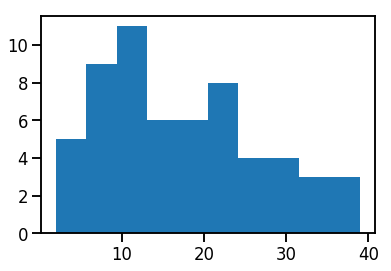

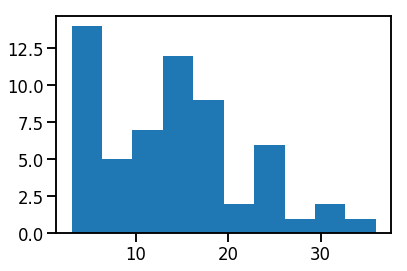

In [146]:
plt.hist(in_es, bins=10)
plt.show()
plt.hist(dn_es, bins=10)
plt.show()

(array([10.,  0., 28.,  0., 17.,  0.,  1.,  0.,  2.,  1.]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]),
 <a list of 10 Patch objects>)

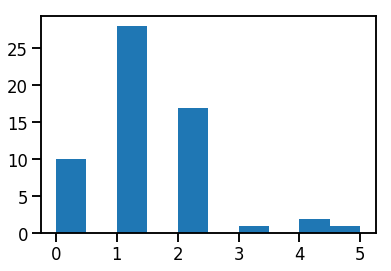

In [152]:
plt.hist(np.random.poisson(size=59), bins=10)

In [150]:
norm_distrib = np.random.normal(size=1000000)

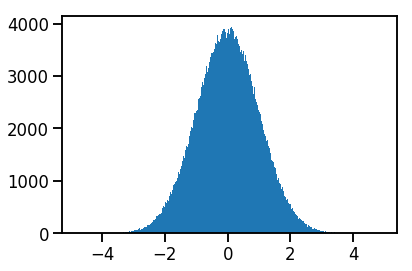

NormaltestResult(statistic=1.2820756372318527, pvalue=0.5267454740158919)

In [106]:
plt.hist(norm_distrib, bins=1000)
plt.show()
normaltest(norm_distrib)

In [109]:
# is the distribution significantly non-normal?
print(f'immediate: {normaltest(in_es)}')
print(f'delayed: {normaltest(dn_es)}')

immediate: NormaltestResult(statistic=4.0348319318921115, pvalue=0.132998694586712)
delayed: NormaltestResult(statistic=4.409905111869654, pvalue=0.11025575616167871)


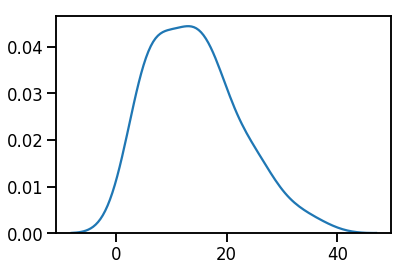

In [48]:
sns.kdeplot([ne[1] for ne in n_events.values()])

## compare total number of UNIQUE events per participant

In [132]:
n_unique_events = dict.fromkeys(id_maps.keys())

for sid in n_unique_events.keys():
    tid1, n_ues1  = next((tid, len(np.unique(es))) for tid, es in imm_matches if tid == id_maps[sid]['session 1'])
    tid2, n_ues2 = next((tid, len(np.unique(es))) for tid, es in del_matches if tid == id_maps[sid]['session 2'])
    n_unique_events[sid] = (n_ues1, n_ues2)

In [164]:
print(np.mean([ne[0] for ne in n_unique_events.values()]))
print(np.mean([ne[1] for ne in n_unique_events.values()]))
print(np.mean([ne[0] for ne in n_unique_events.values()]) - np.mean([ne[1] for ne in n_unique_events.values()]))
in_es_unique = [ne[0] for ne in n_unique_events.values()]
dn_es_unique = [ne[1] for ne in n_unique_events.values()]

11.40677966101695
9.64406779661017
1.7627118644067803


In [165]:
ttest_rel(dn_es_unique, in_es_unique)

Ttest_relResult(statistic=-3.0692785679111516, pvalue=0.003261029054069482)

In [166]:
wilcoxon(dn_es_unique, in_es_unique)

WilcoxonResult(statistic=410.5, pvalue=0.0025349045916531416)

In [167]:
f_oneway(dn_es_unique, in_es_unique)

F_onewayResult(statistic=5.280005386661282, pvalue=0.023363944329985745)

In [35]:
# i_memorability = event_match_distances.loc[pd.IndexSlice[:, 'imm_dist'],'average'][:-1]
# d_memorability = event_match_distances.loc[pd.IndexSlice[:, 'del_dist'],'average'][:-1]

# ev_meandev_i = []
# ev_meandev_d = []
# for ix, event in enumerate(event_match_distances.index.levels[0][:-2]):
    
#     ev_meandev_i.append(np.nanmean([event_match_distances.loc[(event, 'imm_dist'),sub] - i_memorability[event][0] 
#                              for sub in event_match_distances.columns[:-2]]))
#     ev_meandev_d.append(np.nanmean([event_match_distances.loc[(event, 'del_dist'),sub] - d_memorability[event][0] 
#                              for sub in event_match_distances.columns[:-2]]))

In [36]:
# sns.jointplot(i_memorability.tolist(), ev_meandev_i, kind='reg', stat_func=pearsonr)

In [37]:
# sns.regplot(d_memorability.tolist(), ev_meandev_d)

In [38]:
# sns.regplot(i_memorability.tolist(), d_memorability.tolist())

In [39]:
# sns.regplot(ev_meandev_i, ev_meandev_d)

### is number of events recalled related to memory ability?

In [25]:
# n_imm_es = []
# n_del_es = []
# n_diff_es = []
# avg_imm_dist = []
# avg_del_dist = []
# avg_dist_diff = []
# avg_prop_diff = []

# for sid, (imm_n, del_n) in n_events.items():
#     n_imm_es.append(imm_n)
#     n_del_es.append(del_n)
#     n_diff_es.append(imm_n - del_n)
#     avg_imm_dist.append(event_match_distances.at[('average','imm_dist'), sid])
#     avg_del_dist.append(event_match_distances.at[('average','del_dist'), sid])
#     avg_dist_diff.append(event_match_distances.at[('average','diff'), sid])
#     avg_prop_diff.append(event_match_distances.at[('avg_percent_diff',), sid][0])

In [26]:
# # PER SUBJECT number of events recalled vs average episode-recall event distance

# sns.jointplot(n_imm_es, avg_imm_dist, kind='reg', stat_func=pearsonr)
# plt.xlabel('Number of events immediately recalled')
# plt.ylabel('Average episode-recall event distance')
# plt.suptitle('Number of events vs event accuracy', y=1.05)

In [27]:
# # PER SUBJECT number of events immediately recalled vs number of events recalled after delay

# sns.jointplot(n_imm_es, n_del_es, kind='reg', stat_func=pearsonr)
# plt.xlabel('Number of events immediately recalled')
# plt.ylabel('Number of events recalled after delay')
# plt.suptitle('Immediate recall events vs delayed recall events', y=1.05)
# plt.savefig(delfig_dir+'n-events-imm-del.pdf')

In [28]:
# # PER SUBJECT average immediate recall event accuracy vs avreage delayed recall accuracy

# sns.jointplot(avg_imm_dist, avg_del_dist, kind='reg', stat_func=pearsonr)
# plt.xlabel('Average immediate episode-recall event distance')
# plt.ylabel('Average delayed episode-recall event distance')
# plt.suptitle('Immediate event accuracy vs delayed event accuracy', y=1.05)
# plt.savefig(delfig_dir+'imm-del-avg-event-dist.pdf')

In [29]:
# # PER SUBJECT decrease in number of events remembered vs proportional increase in distance

# sns.jointplot(n_del_es, avg_dist_diff, kind='reg', stat_func=pearsonr)
# plt.xlabel('Number of events forgotten during delay')
# plt.ylabel('Proportional decrease in event memory accuracy')
# plt.suptitle('Immediate event accuracy vs delayed event accuracy', y=1.05)
# #plt.savefig(delfig_dir+'imm-del-avg-event-dist.pdf')

### (average of matched events)

In [45]:
# multiindex = pd.MultiIndex.from_product([list(range(len(ep_events)))+['average'], ['imm_dist','del_dist','diff']], 
#                                         names=['event', 'distance'])
# event_match_distances = pd.DataFrame(columns=[k for k in id_maps.keys()], index=multiindex)

# for sid in event_match_distances.columns:
    
#     sub_i_ds = []
#     sub_d_ds = []
#     sub_diffs = []
        
#     # get participant's immediate and delayed recall events and matches
#     sub_i_evs = next(sub_evs for tid, sub_evs in imm_events if tid == id_maps[sid]['session 1'])
#     sub_i_ms = next(sub_ms for tid, sub_ms in imm_matches if tid == id_maps[sid]['session 1'])
    
#     sub_d_evs = next(sub_evs for tid, sub_evs in del_events if tid == id_maps[sid]['session 2'])
#     sub_d_ms = next(sub_ms for tid, sub_ms in del_matches if tid == id_maps[sid]['session 2'])
    

#     # for each episode event
#     for i, ep_e in enumerate(ep_events):
#         # if the subject recalled that event
#         if i in sub_i_ms and i in sub_d_ms:
#             # find the distance between the episode event and closest matching recalled event
#             avgdist_i = np.mean(cdist([ep_e], sub_i_evs[np.where(sub_i_ms == i)], metric='euclidean'))
#             avgdist_d = np.mean(cdist([ep_e], sub_d_evs[np.where(sub_d_ms == i)], metric='euclidean'))
#             avgdist_diff = avgdist_d - avgdist_i
            
#             event_match_distances.at[(i, 'imm_dist'), sid] = avgdist_i
#             event_match_distances.at[(i, 'del_dist'), sid] = avgdist_d
#             event_match_distances.at[(i, 'diff'), sid] = avgdist_diff
            
#             sub_i_ds.append(avgdist_i)
#             sub_d_ds.append(avgdist_d)
#             sub_diffs.append(avgdist_diff)
            
#     event_match_distances.at[('average','imm_dist'), sid] = np.mean(sub_i_ds)
#     event_match_distances.at[('average','del_dist'), sid] = np.mean(sub_d_ds)
#     event_match_distances.at[('average','diff'), sid] = np.mean(sub_diffs)
    
#     event_match_distances.at['avg_percent_diff', sid] = np.mean(sub_diffs) / np.mean(sub_i_ds) 

            
# event_match_distances.dropna(how='all', inplace=True)
# event_match_distances.index = event_match_distances.index.remove_unused_levels()

# event_match_distances['average'] = event_match_distances.mean(axis=1)

# for row in event_match_distances.index.levels[0][:-1]:
#     a_p_d = event_match_distances.at[(row, 'diff'), 'average'] / \
#     event_match_distances.at[(row, 'imm_dist'), 'average']
    
#     event_match_distances.at[(row, 'diff'), 'avg_percent_diff'] = a_p_d

In [46]:
# # RAW distance increase by event
# sns.jointplot(event_match_distances['average'].loc[:, 'imm_dist'][:-1], 
#             event_match_distances['average'].loc[:, 'diff'][:-1], kind='reg', stat_func=pearsonr)
# plt.xlabel('Immediate episode event-recall event distance')
# plt.ylabel('Distance increase immediate to delayed')
# plt.suptitle('Average Information loss by event', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-raw-mean-euclidean-events.pdf')

In [47]:
# # PERCENT distance increase by event
# sns.jointplot(event_match_distances['average'].loc[:, 'imm_dist'][:-1], 
#             event_match_distances['avg_percent_diff'].loc[:, 'diff'][:-1], kind='reg', stat_func=pearsonr)
# plt.xlabel('Immediate episode event-recall event distance')
# plt.ylabel('Percent distance increase immediate to delayed')
# plt.suptitle('Average Information loss by event', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-prop-mean-euclidean-events.pdf')

In [48]:
# # RAW distance increase  by subject

# sns.jointplot(pd.Series(event_match_distances.loc[('average', 'imm_dist')][:-2], dtype='float'), 
#             pd.Series(event_match_distances.loc[('average', 'diff')][:-2], dtype='float'), kind='reg',
#              stat_func=pearsonr)
# plt.xlabel('Average immediate episode event-recall event distance')
# plt.ylabel('Average distance increase immediate to delayed')
# plt.suptitle('Average Information loss by participant', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-raw-mean-euclidean-subs.pdf')

In [49]:
# # PERCENT distance increase by subject
# sns.jointplot(pd.Series(event_match_distances.loc[('average', 'imm_dist')][:-2], dtype='float'), 
#             pd.Series(event_match_distances.loc['avg_percent_diff'].iloc[0][:-2], dtype='float'), kind='reg',
#              stat_func=pearsonr)
# plt.xlabel('Average immediate episode event-recall event distance')
# plt.ylabel('Average percent distance increase immediate to delayed')
# plt.suptitle('Average Information loss by participant', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-prop-mean-euclidean-subs.pdf')

In [50]:
# # repeat event memorability vs accross-subject variability in memory accuracy analysis
# i_memorability = event_match_distances.loc[pd.IndexSlice[:, 'imm_dist'],'average'][:-1]
# d_memorability = event_match_distances.loc[pd.IndexSlice[:, 'del_dist'],'average'][:-1]

# ev_meandev_i = []
# ev_meandev_d = []
# for ix, event in enumerate(event_match_distances.index.levels[0][:-2]):
    
#     ev_meandev_i.append(np.nanmean([event_match_distances.loc[(event, 'imm_dist'),sub] - i_memorability[event][0] 
#                              for sub in event_match_distances.columns[:-2]]))
#     ev_meandev_d.append(np.nanmean([event_match_distances.loc[(event, 'del_dist'),sub] - d_memorability[event][0] 
#                              for sub in event_match_distances.columns[:-2]]))

In [51]:
# sns.regplot(i_memorability.tolist(), ev_meandev_i)

In [52]:
# sns.regplot(d_memorability.tolist(), ev_meandev_d)

In [53]:
# sns.regplot(i_memorability.tolist(), d_memorability.tolist())

In [54]:
# sns.regplot(ev_meandev_i, ev_meandev_d)

## compare topic vector correlation between each recall event and corresponding episode event

### (matched event with highest correlation)

In [364]:
multiindex = pd.MultiIndex.from_product([list(range(len(episode_events)))+['average'], ['imm_corr','del_corr','diff']], 
                                        names=['event', 'correlation'])
event_match_corrs = pd.DataFrame(columns=[k for k in id_maps.index], index=multiindex)


In [365]:
event_match_corrs

MD-101218-A-01 MD-101218-B-01 MD-101218-A-02  \
event   correlation                                                
0       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
1       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
...                            ...            ...            ...   
28      del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
average imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   

                    MD-101218-B-02 MD-101218-A-03 MD-101218-B-03  \
event   correlation                                                
0       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
1       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
...                            ...            ...            ...   
28      del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
average imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   

                    MD-101218-A-04 MD-101318-B-01 MD-101318-B-02  \
event   correlation                                                
0       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
1       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
...                            ...            ...            ...   
28      del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
average imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   

                    MD-101318-A-02  ... MD-021519-A-01 MD-021819-B-01  \
event   correlation                 ...                                 
0       imm_corr               NaN  ...            NaN            NaN   
        del_corr               NaN  ...            NaN            NaN   
        diff                   NaN  ...            NaN            NaN   
1       imm_corr               NaN  ...            NaN            NaN   
        del_corr               NaN  ...            NaN            NaN   
...                            ...  ...            ...            ...   
28      del_corr               NaN  ...            NaN            NaN   
        diff                   NaN  ...            NaN            NaN   
average imm_corr               NaN  ...            NaN            NaN   
        del_corr               NaN  ...            NaN            NaN   
        diff                   NaN  ...            NaN            NaN   

                    MD-021819-B-02 MD-021919-A-01 MD-021919-B-01  \
event   correlation                                                
0       imm_corr               NaN            NaN            NaN   
        del_corr               NaN            NaN            NaN   
        diff                   NaN            NaN            NaN   
1       imm_corr               NaN            NaN            NaN   
       

In [30]:
multiindex = pd.MultiIndex.from_product([list(range(len(ep_events)))+['average'], ['imm_corr','del_corr','diff']], 
                                        names=['event', 'correlation'])
event_match_corrs = pd.DataFrame(columns=[k for k in id_maps.keys()], index=multiindex)

for sid in event_match_corrs.columns:
    
    sub_i_cs = []
    sub_d_cs = []
    sub_diffs = []
        
    # get participant's immediate and delayed recall events and matches
    sub_i_evs = next(sub_evs for tid, sub_evs in imm_events if tid == id_maps[sid]['session 1'])
    sub_i_ms = next(sub_ms for tid, sub_ms in imm_matches if tid == id_maps[sid]['session 1'])
    
    sub_d_evs = next(sub_evs for tid, sub_evs in del_events if tid == id_maps[sid]['session 2'])
    sub_d_ms = next(sub_ms for tid, sub_ms in del_matches if tid == id_maps[sid]['session 2'])
    

    # for each episode event
    for i, ep_e in enumerate(ep_events):
        # if the subject recalled that event
        if i in sub_i_ms and i in sub_d_ms:
            # compute the correlation between the episode event and most highly correlated matching recalled event
            maxcorr_i = np.max(1-cdist([ep_e], sub_i_evs[np.where(sub_i_ms == i)], metric='correlation'))
            maxcorr_d = np.max(1-cdist([ep_e], sub_d_evs[np.where(sub_d_ms == i)], metric='correlation'))
            maxcorr_diff = maxcorr_i - maxcorr_d
            
            event_match_corrs.at[(i, 'imm_corr'), sid] = maxcorr_i
            event_match_corrs.at[(i, 'del_corr'), sid] = maxcorr_d
            event_match_corrs.at[(i, 'diff'), sid] = maxcorr_diff
            
            sub_i_cs.append(maxcorr_i)
            sub_d_cs.append(maxcorr_d)
            sub_diffs.append(maxcorr_diff)
            
    event_match_corrs.at[('average','imm_corr'), sid] = corr_mean(sub_i_cs)
    event_match_corrs.at[('average','del_corr'), sid] = corr_mean(sub_d_cs)
    event_match_corrs.at[('average','diff'), sid] = corr_mean(sub_diffs)
    
    event_match_corrs.at['avg_percent_diff', sid] = corr_mean(sub_diffs) / corr_mean(sub_i_cs)
            
event_match_corrs.dropna(how='all', inplace=True)
event_match_corrs.index = event_match_corrs.index.remove_unused_levels()

#event_match_corrs = event_match_corrs.astype('float64')
event_match_corrs['average'] = corr_mean(event_match_corrs.astype('float64').values, axis=1)

for row in event_match_corrs.index.levels[0][:-1]:
    a_p_d = event_match_corrs.at[(row, 'diff'), 'average'] / event_match_corrs.at[(row, 'imm_corr'), 'average']
    
    event_match_corrs.at[(row, 'diff'), 'avg_percent_diff'] = a_p_d

0.3644645590309344 0.03720806619206381


Text(0.5,1.05,'Average precision loss\nby event')

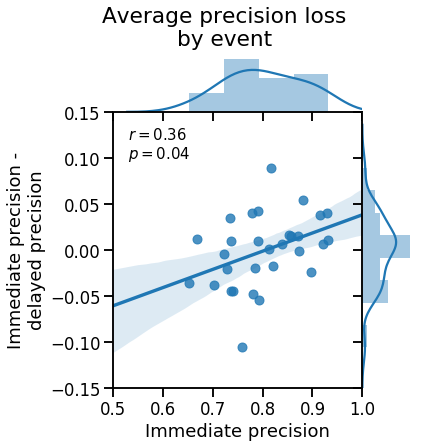

In [31]:
# # for each EVENT, relate distance to RAW information loss (raw correlation decrease)

# sns.set_context('talk')
sns.jointplot(event_match_corrs['average'].loc[:, 'imm_corr'][:-1], 
            event_match_corrs['average'].loc[:, 'diff'][:-1], kind='reg', space=0, xlim=(0.5,1), ylim=(-.15,.15))
r,p = corr_pearsonr(event_match_corrs['average'].loc[:, 'imm_corr'][:-1], event_match_corrs['average'].loc[:, 'diff'][:-1])
print(r,p)
r,p = str(round(r, 2)), str(round(p, 2))
plt.text(.53,0.12, f'$r={r}$', ha='left', fontsize=15)   
plt.text(.53,0.1, f'$p={p}$', ha='left', fontsize=15)
plt.xlabel('Immediate precision')
plt.ylabel('Immediate precision -\ndelayed precision')
plt.suptitle('Average precision loss\nby event', y=1.05)
# plt.tight_layout()
# plt.savefig(delfig_dir+'delay-loss-raw-best-corr-events.pdf')

In [32]:
# # for each event, relate distance to PERCENT information loss (percent correlation decrease)

# sns.jointplot(event_match_corrs['average'].loc[:, 'imm_corr'][:-1], 
#             event_match_corrs['avg_percent_diff'].loc[:, 'diff'][:-1], kind='reg', stat_func=pearsonr)
# plt.xlabel('Immediate episode event-recall event correlation')
# plt.ylabel('Percent correlation change immediate to delayed')
# plt.suptitle('Average Information loss by event', y=1.05)
# # plt.savefig(delfig_dir+'delay-loss-prop-best-corr-events.pdf')

0.46274153717519745 5.3551259324017625e-05


Text(0.5,1.05,'Average precision loss\nby participant')

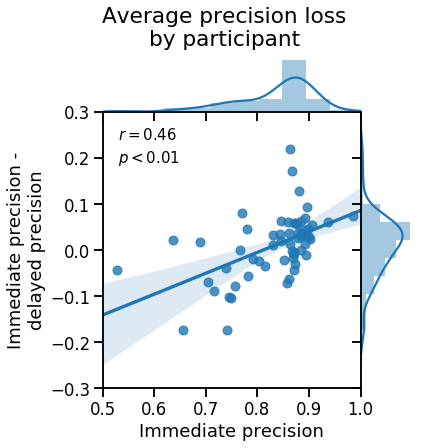

In [33]:
# for each PARTICIPANT, relate average correlation to RAW information loss (raw correlation decrease)

sns.jointplot(pd.Series(event_match_corrs.loc[('average', 'imm_corr')][:-2], dtype='float'), 
            pd.Series(event_match_corrs.loc[('average', 'diff')][:-2], dtype='float'), kind='reg', space=0, 
              xlim=(0.5,1), ylim=(-.3,.3))
r,p = corr_pearsonr(pd.Series(event_match_corrs.loc[('average', 'imm_corr')][:-2], dtype='float'), 
            pd.Series(event_match_corrs.loc[('average', 'diff')][:-2], dtype='float'))
print(r,p)
r = str(round(r, 2))
p = 0.01
plt.text(.53,0.24, f'$r={r}$', ha='left', fontsize=15)   
plt.text(.53,0.19, f'$p<{p}$', ha='left', fontsize=15)
plt.xlabel('Immediate precision')
plt.ylabel('Immediate precision -\ndelayed precision')
plt.suptitle('Average precision loss\nby participant', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-raw-best-corr-subs.pdf')

In [34]:
# # for each participant, relate average correlation to PERCENT information loss (percent correlation decrease)

# sns.jointplot(pd.Series(event_match_corrs.loc[('average', 'imm_corr')][:-2], dtype='float'), 
#             pd.Series(event_match_corrs.loc['avg_percent_diff'].iloc[0][:-2], dtype='float'), kind='reg',
#              stat_func=pearsonr)
# plt.xlabel('Average immediate episode event-recall event correlation')
# plt.ylabel('Average percent correlation change immediate to delayed')
# plt.suptitle('Average Information loss by participant', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-prop-best-corr-subs.pdf')

In [35]:
n_imm_es = []
n_del_es = []
n_diff_es = []
avg_imm_corr = []
avg_del_corr = []
avg_corr_diff = []
avg_prop_diff = []

for sid, (imm_n, del_n) in n_events.items():
    n_imm_es.append(imm_n)
    n_del_es.append(del_n)
    n_diff_es.append(imm_n - del_n)
    avg_imm_corr.append(event_match_corrs.at[('average','imm_corr'), sid])
    avg_del_corr.append(event_match_corrs.at[('average','del_corr'), sid])
    avg_corr_diff.append(event_match_corrs.at[('average','diff'), sid])
    avg_prop_diff.append(event_match_corrs.at[('avg_percent_diff',), sid][0])

0.5124062847383706 2.9862308551939787e-06


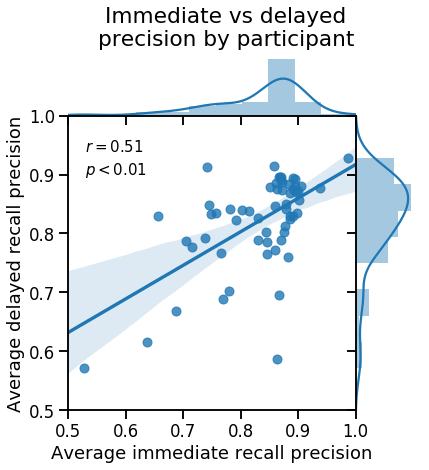

In [165]:
# PER SUBJECT average immediate recall event accuracy vs avreage delayed recall accuracy

sns.jointplot(avg_imm_corr, avg_del_corr, kind='reg', space=0, xlim=(0.5,1), ylim=(.5,1))
r, p = corr_pearsonr(avg_imm_corr, avg_del_corr)
print(r,p)
r = str(round(r, 2))
p = 0.01
plt.text(.53,0.94, f'$r={r}$', ha='left', fontsize=15)   
plt.text(.53,0.9, f'$p<{p}$', ha='left', fontsize=15)
plt.xlabel('Average immediate recall precision')
plt.ylabel('Average delayed recall precision')
plt.suptitle('Immediate vs delayed\nprecision by participant', y=1.05)
plt.savefig(delfig_dir+'imm-del-avg-sub-corr.pdf')

In [158]:
ev_icorrs = []
ev_dcorrs = []
for ix, ev in event_match_corrs.iterrows():
    if 'average' in ix:
        break
    elif 'imm_corr' in ix:
        ev_icorrs.append(ev['average'])
    elif 'del_corr' in ix:
        ev_dcorrs.append(ev['average'])
    else:
        print(ix[1])


diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff
diff


In [61]:
ev_icorrs = []
ev_dcorrs = []

for i in range(32):
    ev_icorrs.append(event_match_corrs.loc[i, 'imm_corr']['average'])
    ev_dcorrs.append(event_match_corrs.loc[i, 'del_corr']['average'])

KeyError: 'the label [10] is not in the [index]'

0.705181324906348 1.9475188125044035e-10


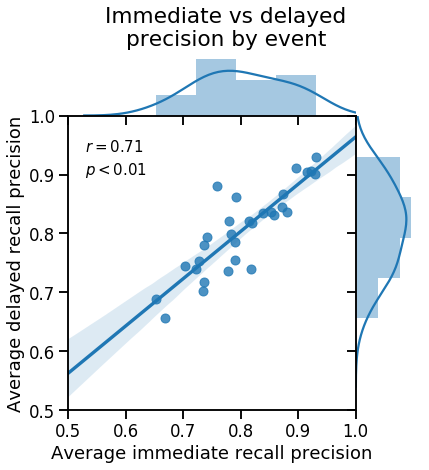

In [164]:
# PER event average immediate recall event accuracy vs avreage delayed recall accuracy

sns.jointplot(ev_icorrs, ev_dcorrs, kind='reg', space=0, xlim=(0.5,1), ylim=(.5,1))
r, p = corr_pearsonr(ev_icorrs, ev_dcorrs)
print(r,p)
r = str(round(r, 2))
p = 0.01
plt.text(.53,0.94, f'$r={r}$', ha='left', fontsize=15)   
plt.text(.53,0.9, f'$p<{p}$', ha='left', fontsize=15)
plt.xlabel('Average immediate recall precision')
plt.ylabel('Average delayed recall precision')
plt.suptitle('Immediate vs delayed\nprecision by event', y=1.05)
plt.savefig(delfig_dir+'imm-del-avg-event-corr.pdf')

In [157]:
event_match_corrs

MD-101218-A-01 MD-101218-B-01 MD-101218-A-02  \
event            correlation                                                
0                imm_corr               NaN            NaN            NaN   
                 del_corr               NaN            NaN            NaN   
                 diff                   NaN            NaN            NaN   
1                imm_corr               NaN            NaN            NaN   
                 del_corr               NaN            NaN            NaN   
                 diff                   NaN            NaN            NaN   
2                imm_corr          0.915169            NaN            NaN   
                 del_corr            0.9686            NaN            NaN   
                 diff            -0.0534306            NaN            NaN   
3                imm_corr               NaN            NaN            NaN   
                 del_corr               NaN            NaN            NaN   
                 diff                   NaN            NaN            NaN   
4                imm_corr               NaN            NaN            NaN   
                 del_corr               NaN            NaN            NaN   
                 diff                   NaN            NaN            NaN   
5                imm_corr               NaN            NaN            NaN   
                 del_corr               NaN            NaN            NaN   
                 diff                   NaN            NaN            NaN   
6                imm_corr               NaN            NaN            NaN   
                 del_corr               NaN            NaN            NaN   
                 diff                   NaN            NaN            NaN   
7                imm_corr          0.769222            NaN       0.741226   
                 del_corr          0.834728            NaN       0.913549   
                 diff            -0.0655063            NaN      -0.172322   
8                imm_corr               NaN            NaN            NaN   
                 del_corr               NaN            NaN            NaN   
                 diff                   NaN            NaN            NaN   
9                imm_corr          0.713918            NaN            NaN   
                 del_corr          0.630477            NaN            NaN   
                 diff             0.0834411            NaN            NaN   
...                                     ...            ...            ...   
23               del_corr               NaN            NaN            NaN   
                 diff                   NaN            NaN            NaN   
24               imm_corr               NaN            NaN            NaN   
                 del_corr               NaN            NaN            NaN   
                 diff                   NaN            NaN            NaN   
25               imm_corr               NaN       0.668825            NaN   
                 del_corr               NaN       0.656481            NaN   
                 diff                   NaN      0.0123444            NaN   
26               imm_corr               NaN            NaN            NaN   
                 del_corr               NaN            NaN            NaN   
                 diff                   NaN            NaN            NaN   
27               imm_corr           0.90028            NaN            NaN   
                 del_corr          0.707765            NaN            NaN   
                 diff              0.192515            NaN            NaN   
28               imm_corr               NaN            NaN            NaN   
                 del_corr               NaN            NaN            NaN   
                 diff                   NaN            NaN            NaN   
29               imm_corr               NaN            NaN            NaN   
                 del_corr               NaN            NaN            NaN   
                 diff    

### (average of matched events)

In [34]:
# multiindex = pd.MultiIndex.from_product([list(range(len(ep_events)))+['average'], ['imm_corr','del_corr','diff']], 
#                                         names=['event', 'correlation'])
# event_match_corrs = pd.DataFrame(columns=[k for k in id_maps.keys()], index=multiindex)

# for sid in event_match_corrs.columns:
    
#     sub_i_cs = []
#     sub_d_cs = []
#     sub_diffs = []
        
#     # get participant's immediate and delayed recall events and matches
#     sub_i_evs = next(sub_evs for tid, sub_evs in imm_events if tid == id_maps[sid]['session 1'])
#     sub_i_ms = next(sub_ms for tid, sub_ms in imm_matches if tid == id_maps[sid]['session 1'])
    
#     sub_d_evs = next(sub_evs for tid, sub_evs in del_events if tid == id_maps[sid]['session 2'])
#     sub_d_ms = next(sub_ms for tid, sub_ms in del_matches if tid == id_maps[sid]['session 2'])
    

#     # for each episode event
#     for i, ep_e in enumerate(ep_events):
#         # if the subject recalled that event
#         if i in sub_i_ms and i in sub_d_ms:
#             # compute the correlation between the episode event and most highly correlated matching recalled event
#             meancorr_i = corr_mean(1-cdist([ep_e], sub_i_evs[np.where(sub_i_ms == i)], metric='correlation'), axis=1)[0]
#             meancorr_d = corr_mean(1-cdist([ep_e], sub_d_evs[np.where(sub_d_ms == i)], metric='correlation'), axis=1)[0]
#             meancorr_diff = meancorr_d - meancorr_i
            
#             event_match_corrs.at[(i, 'imm_corr'), sid] = meancorr_i
#             event_match_corrs.at[(i, 'del_corr'), sid] = meancorr_d
#             event_match_corrs.at[(i, 'diff'), sid] = meancorr_diff
            
#             sub_i_cs.append(meancorr_i)
#             sub_d_cs.append(meancorr_d)
#             sub_diffs.append(meancorr_diff)
            
#     event_match_corrs.at[('average','imm_corr'), sid] = corr_mean(sub_i_cs)
#     event_match_corrs.at[('average','del_corr'), sid] = corr_mean(sub_d_cs)
#     event_match_corrs.at[('average','diff'), sid] = corr_mean(sub_diffs)
    
#     event_match_corrs.at['avg_percent_diff', sid] = corr_mean(sub_diffs) / corr_mean(sub_i_cs)

# event_match_corrs.dropna(how='all', inplace=True)
# event_match_corrs.index = event_match_corrs.index.remove_unused_levels()

# event_match_corrs['average'] = corr_mean(event_match_corrs.astype('float64').values, axis=1)

# for row in event_match_corrs.index.levels[0][:-1]:
#     a_p_d = event_match_corrs.at[(row, 'diff'), 'average'] / event_match_corrs.at[(row, 'imm_corr'), 'average']
    
#     event_match_corrs.at[(row, 'diff'), 'avg_percent_diff'] = a_p_d

In [61]:
# # for each event, relate distance to RAW information loss (raw correlation decrease)

# sns.jointplot(event_match_corrs['average'].loc[:, 'imm_corr'][:-1], 
#             event_match_corrs['average'].loc[:, 'diff'][:-1], kind='reg', stat_func=pearsonr)
# plt.xlabel('Immediate episode event-recall event correlation')
# plt.ylabel('Correlation change immediate to delayed')
# plt.suptitle('Average Information loss by event', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-raw-mean-corr-events.pdf')

In [206]:
# # for each event, relate distance to PERCENT information loss (percent correlation decrease)

# sns.jointplot(event_match_corrs['average'].loc[:, 'imm_corr'][:-1], 
#             event_match_corrs['avg_percent_diff'].loc[:, 'diff'][:-1], kind='reg', stat_func=pearsonr)
# plt.xlabel('Immediate episode event-recall event correlation')
# plt.ylabel('Percent correlation change immediate to delayed')
# plt.suptitle('Average Information loss by event', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-prop-mean-corr-events.pdf')

In [207]:
# # for each participant, relate average correlation to RAW information loss (raw correlation decrease)

# sns.jointplot(pd.Series(event_match_corrs.loc[('average', 'imm_corr')][:-2], dtype='float'), 
#             pd.Series(event_match_corrs.loc[('average', 'diff')][:-2], dtype='float'), kind='reg', 
#           stat_func=pearsonr)
# plt.xlabel('Average immediate episode event-recall event correlation')
# plt.ylabel('Average correlation change immediate to delayed')
# plt.suptitle('Average Information loss by participant', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-raw-mean-corr-subs.pdf')

In [208]:
# # for each participant, relate average correlation to PERCENT information loss (percent correlation decrease)

# sns.jointplot(pd.Series(event_match_corrs.loc[('average', 'imm_corr')][:-2], dtype='float'), 
#             pd.Series(event_match_corrs.loc['avg_percent_diff'].iloc[0][:-2], dtype='float'), kind='reg',
#              stat_func=pearsonr)
# plt.xlabel('Average immediate episode event-recall event correlation')
# plt.ylabel('Average percent correlation change immediate to delayed')
# plt.suptitle('Average Information loss by participant', y=1.05)
# plt.savefig(delfig_dir+'delay-loss-prop-mean-corr-subs.pdf')